<a href="https://colab.research.google.com/github/hindxb/FDS/blob/main/Notebooks/Class%20Activities/Hind_Alzarooni_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [38]:
#Install the datascience library for tables, charts, etc
!pip install datascience

#Import everything (*) from the package
from datascience import *

#Import NumPy for neumerical operations which include making arrays, calculations, etc.
import numpy as np

#Import matplotlib to help with plotting the graphs and visualizations
import matplotlib.pyplot as plt

#Set the plotting style which makes the graphs look cleaner
plt.style.use('fivethirtyeight')

#plots will show up directly below the code
%matplotlib inline

In [39]:
#Import everything (*) from the package
from datascience import *

#plots will show up directly below the code
%matplotlib inline
#path_data = '../../../assets/data/'

#Import matplotlib to help with plotting the graphs and visualizations
import matplotlib.pyplot as plt

#Set the plotting style which makes the graphs look cleaner
plt.style.use('fivethirtyeight')

#Import NumPy for neumerical operations which include making arrays, calculations, etc.
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [40]:
#Load dataset

#Uploading the kaggle dowloaded dataset file to this colab environment from your computer
from google.colab import files
iris_dataset = files.upload()

#read the csv file and save it to the table named "iris_table"
iris_table = Table.read_table( 'Iris.csv')
iris_table

Saving Iris.csv to Iris (1).csv


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [41]:
# Q1. How many rows and columns does the dataset have? Print the column names.

#printing the number of rows in the tables
print("The number of rows in the table is", iris_table.num_rows, "rows")

#printing the number of columns in the table
print("The number of columns in the table is", iris_table.num_columns, "columns")

#printing all column names in the table
print("The column names are", iris_table.labels)


The number of rows in the table is 150 rows
The number of columns in the table is 6 columns
The column names are ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [42]:
# Q2. How many flowers are there per species? Use the .group() method.

#grouping all the species together, there are 3 species
iris_count = iris_table.group('Species')

#displaying how many flowers data there are per species
iris_count

Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [43]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.

#Saving all the data in the PetalLengthCm and PetalWidthCm in an array
petal_length = iris_table.column('PetalLengthCm')
petal_width = iris_table.column('PetalWidthCm')

#Finding the maximum value in the PetalWidthCm and PetalLengthCm columns
max_petal_length = np.max(petal_length)
max_petal_width = np.max(petal_width)

#Finding the minimum value in the PetalWidthCm and PetalLengthCm columns
min_petal_length = np.min(petal_length)
min_petal_width = np.min(petal_width)

#Finding the mean value of the PetalWidthCm and PetalLengthCm columns
mean_petal_length = np.mean(petal_length)
mean_petal_width = np.mean(petal_width)

#printing the maximum petal values
print("The maximum petal length is", max_petal_length, "cm")
print("The maximum petal width is", max_petal_width, "cm")

#printing the minimum petal values
print("\nThe minimum petal length is", min_petal_length, "cm")
print("The minimum petal width is", min_petal_width, "cm")

#printing the mean petal values
print("\nThe mean petal length is", round(mean_petal_length,4), "cm")
print("The mean petal width is", round(mean_petal_width,4), "cm")

The maximum petal length is 6.9 cm
The maximum petal width is 2.5 cm

The minimum petal length is 1.0 cm
The minimum petal width is 0.1 cm

The mean petal length is 3.7587 cm
The mean petal width is 1.1987 cm


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

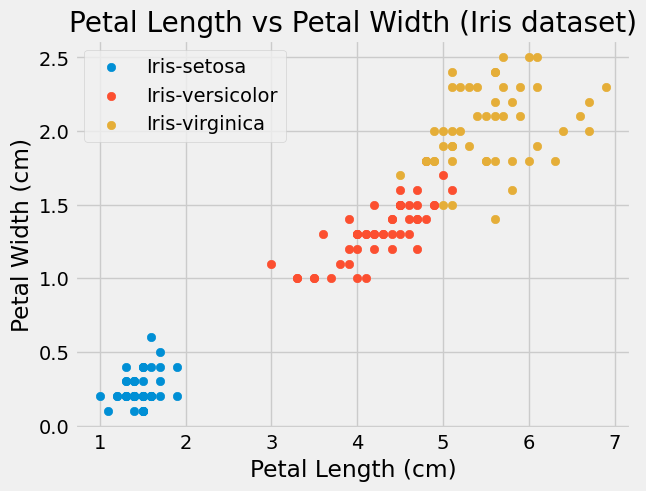

In [44]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.

#Separate the table based on the species, each species is saved in a different table
species1 = iris_table.where("Species", "Iris-setosa")
species2 = iris_table.where("Species", "Iris-versicolor")
species3 = iris_table.where("Species", "Iris-virginica")

#this will plot each species in a different color
#the petal lenth will be on the x-axis and the petal width will be on the y-axis
plt.scatter(species1.column("PetalLengthCm"), species1.column("PetalWidthCm"), label="Iris-setosa")
plt.scatter(species2.column("PetalLengthCm"), species2.column("PetalWidthCm"), label="Iris-versicolor")
plt.scatter(species3.column("PetalLengthCm"), species3.column("PetalWidthCm"), label="Iris-virginica")

#adjusting the title for the plot
plt.title("Petal Length vs Petal Width (Iris dataset)")

#adjusting x-axis label for the plot
plt.xlabel("Petal Length (cm)")

#adjusting y-axis label for the plot
plt.ylabel("Petal Width (cm)")

#adding legends so you know which species is which color
plt.legend()
plt.show()



#I know I can just do the following but i wanted to do extra to make the graph look presentable

#create the scatter plot with the length and the width of the petal
#iris_table.scatter('PetalLengthCm', 'PetalWidthCm')

#Add a title to the graph to describe what it represents
#plt.title("Petal Length vs Petal Width (iris dataset)")


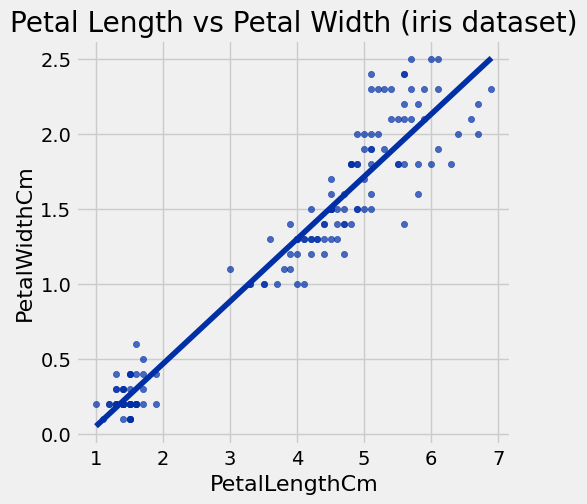

In [45]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.

#creating a scatter plot from the table with the specified columns and setting the line as true
iris_table.scatter('PetalLengthCm', 'PetalWidthCm', fit_line=True)

#Add a title to the graph to describe what it represents
plt.title("Petal Length vs Petal Width (iris dataset)")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------------------------------------------

#Describe the pattern you observe between the two variables.

#The regression line shows a clear positive linear relationship between the petal length feature and the petal width. As one increases the other also increases
#which shows a strong correlation between the variables as evidenced by the clustering formed around the straight line.


## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [46]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [47]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [48]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [49]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [50]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.

#Use the provided helper functions to calculate the slope and the interscept
petal_slope = slope(iris_table, 'PetalLengthCm', 'PetalWidthCm')
petal_intercept = intercept(iris_table, 'PetalLengthCm', 'PetalWidthCm')

#print the slope and the intercept of the regression line
print("The slope of the regression line is computed as ", round(petal_slope,4))
print("The intercept of the regression line is computed as", round(petal_intercept,4))

#print the regression equation line (y=mx+b)
print("The regression line equation is Petalwidth =", round(petal_slope,4), "(Petallength)", f"{round(petal_intercept,4):+}")

#Write the full regression equation.
print()


#The line is petal_width = 0.4164 (petal_length) - 0.3665


The slope of the regression line is computed as  0.4164
The intercept of the regression line is computed as -0.3665
The regression line equation is Petalwidth = 0.4164 (Petallength) -0.3665



In [51]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.

#defining the equation and substituting all variables such as slope, intercept and the length who's width we are predicting
new_petal_length = 4.5
new_petal_width = ( new_petal_length * petal_slope ) + petal_intercept

#printing the result of the predictions
print("The predicted petal width of (petal_length=4.5 cm) is", round(new_petal_width,4), "cm")

#-----------------------------------------------------------------------------------------------------------------------

#show your calculation

#multiply petal_length by the slope = 0.42 * 4.5 = 1.89
#add the intercept = - 0.37
#1.89 - 0.37 = 2.26


The predicted petal width of (petal_length=4.5 cm) is 1.5074 cm


In [52]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

#compute the correlation by using the helper function provided
r = correlation(iris_table,  'PetalLengthCm', 'PetalWidthCm')
print("The correlation coefficient r between petal_length and petal_width is", round(r,4))

#----------------------------------------------------------------------------------------------------------------------------------------------------------------------

#Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

#Since the colleration is rounded to 0.9628 which is close to 1, this indicates that there is a strong positive correlation between petal_length and petal_width.
#So the increase in petal length causes an increase in the petal width in a very close to linear way (indicate the strength of this relationship)


The correlation coefficient r between petal_length and petal_width is 0.9628


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [53]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.

def regression_line(x):
    '''
    function to calculate the regression line
    '''
    return (x * petal_slope) + petal_intercept

#This will find the predicted width based on all the petal lengths and save it as a new column in the table
iris_predictions = iris_table.with_column( "Predicted petal width", iris_table.apply(regression_line, "PetalLengthCm"))

#this will find all the residuals (difference) and add it in the same table that we started with (original iris dataset table)
iris_table= iris_predictions.with_column( "Residuals", iris_predictions.column("PetalWidthCm") - iris_predictions.column("Predicted petal width"))

#show first 8 rows only
iris_table.show(8)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted petal width,Residuals
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


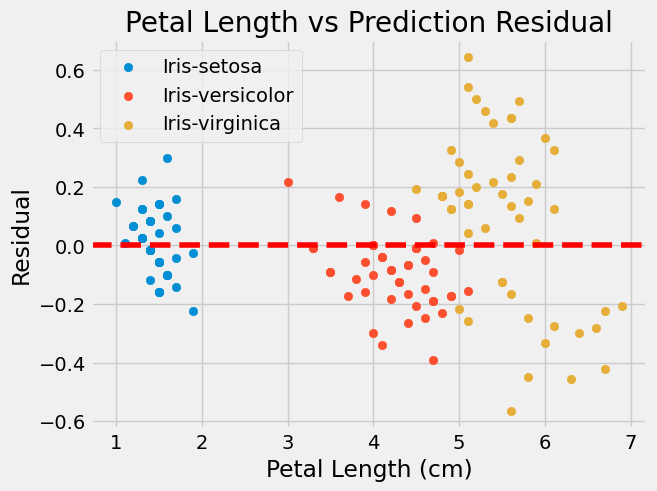

In [54]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.

#Separate the table based on the species, each species is saved in a different table
species1 = iris_table.where("Species", "Iris-setosa")
species2 = iris_table.where("Species", "Iris-versicolor")
species3 = iris_table.where("Species", "Iris-virginica")

#this will plot each species in a different color
#the petal lenth will be on the x-axis and the residual will be on the y-axis
plt.scatter(species1.column("PetalLengthCm"), species1.column("Residuals"), label="Iris-setosa")
plt.scatter(species2.column("PetalLengthCm"), species2.column("Residuals"), label="Iris-versicolor")
plt.scatter(species3.column("PetalLengthCm"), species3.column("Residuals"), label="Iris-virginica")

#horizontal red dashed line at y = 0
plt.axhline(0, color='red', linestyle='--')

#adjusting the title for the plot
plt.title("Petal Length vs Prediction Residual")

#adjusting x-axis label for the plot
plt.xlabel("Petal Length (cm)")

#adjusting y-axis label for the plot
plt.ylabel("Residual")

#adding legends so you know which species is which color
plt.legend()
plt.show()


#In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.

#The scatter of the residual around zero is not random and there is a clear pattern to the clusters based on different iris species.
#The setosa which has smaller petals have residues closer to zero which indicate that the line is a good fit for it. Versicolor is just slightly worse than setosa when it comes to the prediction.
#However, virginica is showing a stronger deviation above and below the y=0 line so the model doesnt capture the full relationship for all the groups/species between petal length and width.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.